# Notebook 03: Baseline Modelling and Robustness Analysis

**Objective:** This notebook evaluates the baseline clustering models using the preprocessed matrices generated in Notebook 02. We will analyze internal validation metrics, assess cluster stability via Bootstrap ARI for different scaling variants (Standard vs. Robust), and profile the optimal segments using post-hoc analysis[cite: 1, 4, 5].

**Experiment Documentation:**
* **Baseline Method:** K-Means (Testing $K \in [3, 4, 5, 6, 7, 8, 11, 14]$)[cite: 2].
* **Robustness Check:** R-EUCLID-standard vs. R-EUCLID-robust to check sensitivity to outliers[cite: 1, 4].
* **Validation Metrics:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, and pairwise Adjusted Rand Index (ARI)[cite: 2].
* **Profiling Rule:** Leakage variables (`is_canceled`, `adr`) are strictly excluded from the input space and reintegrated here solely for cluster interpretation[cite: 3, 4].

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import itertools
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150

FIG_DIR = "../figures/"
TAB_DIR = "../tables/"
for d in [FIG_DIR, TAB_DIR]: os.makedirs(d, exist_ok=True)

log_path = '../tables/experiments.csv'
if os.path.exists(log_path):
    df = pd.read_csv(log_path)
else:
    print("Error: experiments.csv not found. Please run `python run_all.py` from the project root first.")

## 3.1 Internal Validation Metrics
We begin by summarizing the internal validation metrics across different values of $K$[cite: 2]. This helps us evaluate cluster cohesion and separation to narrow down the optimal number of segments before assessing their stability.

Resume of K-Means metrics per K:


silhouette                 davies_bouldin                  \
         mean     std     max           mean     std     min   
k                                                              
3      0.1525  0.0179  0.1779         2.0199  0.1596  1.8321   
4      0.1434  0.0126  0.1657         1.8919  0.2087  1.5645   
5      0.1501  0.0087  0.1589         1.8233  0.1122  1.6753   
6      0.1472  0.0075  0.1605         1.8041  0.0863  1.7193   
7      0.1421  0.0081  0.1597         1.8420  0.1184  1.6904   
8      0.1475  0.0107  0.1615         1.8314  0.1534  1.6451   
11     0.1410  0.0118  0.1591         1.8311  0.1992  1.5616   
14     0.1342  0.0142  0.1595         1.8389  0.2059  1.5532   

   calinski_harabasz                         
                mean        std         max  
k                                            
3         17214.1991  1574.4289  18949.8173  
4         16748.7175  1042.3271  17926.8855  
5         15982.2741   418.3852  16451.5085  
6         15261.4580   639.8933  16131.3942  
7         14395.3396   856.9200  15557.9316  
8         13558.7456  1008.6660  14923.0680  
11        11484.3219  1068.7790  13006.7874  
14        10167.0196  1021.8732  11652.0799

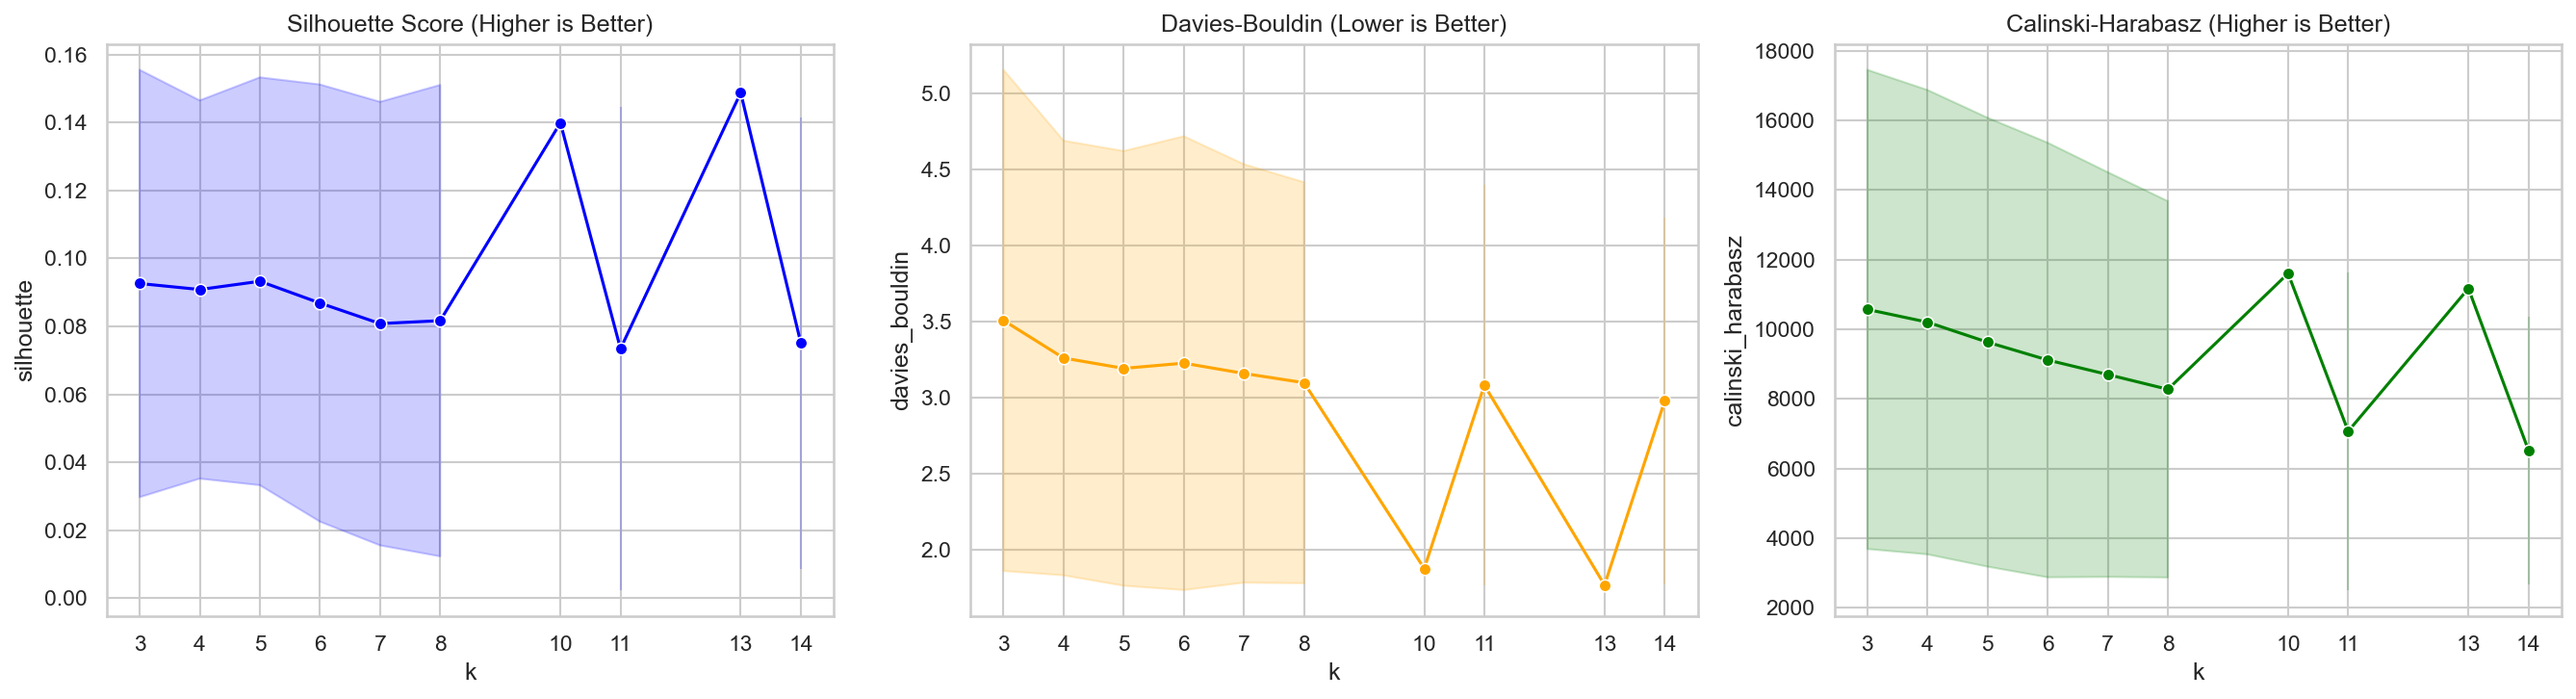

In [2]:
df_kmeans = df[df['method'] == 'k-means'].copy()

resumo_k = df_kmeans.groupby('k').agg({
    'silhouette': ['mean', 'std', 'max'],
    'davies_bouldin': ['mean', 'std', 'min'],
    'calinski_harabasz': ['mean', 'std', 'max']
}).round(4)

print("Resume of K-Means metrics per K:")
display(resumo_k)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Silhouette
sns.lineplot(data=df, x='k', y='silhouette', marker='o', errorbar='sd', ax=axes[0], color='blue')
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].set_xticks(df['k'].unique())

# Plot Davies-Bouldin
sns.lineplot(data=df, x='k', y='davies_bouldin', marker='o', errorbar='sd', ax=axes[1], color='orange')
axes[1].set_title('Davies-Bouldin (Lower is Better)')
axes[1].set_xticks(df['k'].unique())

# Plot Calinski-Harabasz
sns.lineplot(data=df, x='k', y='calinski_harabasz', marker='o', errorbar='sd', ax=axes[2], color='green')
axes[2].set_title('Calinski-Harabasz (Higher is Better)')
axes[2].set_xticks(df['k'].unique())

resumo_k.to_csv(os.path.join(TAB_DIR, 'cluster_metrics_by_k_summary.csv'))
fig.savefig(os.path.join(FIG_DIR, 'cluster_metrics_by_k.png'), bbox_inches='tight')

plt.tight_layout()
plt.show()

## 3.2 Representation Robustness and Cluster Stability
As defined in our data governance strategy, we must ensure our clusters are not solely driven by extreme outliers or heavy tails[cite: 4]. We test the stability of our K-Means models using a bootstrap resampling technique (calculating the pairwise Adjusted Rand Index - ARI) across both the Standard and Robust scaled matrices[cite: 1, 2].

In [3]:
X_scaled_standard = pd.read_csv('../tables/X_scaled_matrix_standard.csv').values
X_scaled_robust = pd.read_csv('../tables/X_scaled_matrix_robust.csv').values

In [ ]:
def kmeans_bootstrap_stability(X, K, n_boot=20, seed=0):
    if isinstance(X, pd.DataFrame):
        X = X.values
        
    n_samples = X.shape[0]
    boot_indices = []
    boot_labels = []

    for i in range(n_boot):
        indices = resample(np.arange(n_samples), random_state=seed+i)
        X_boot = X[indices]

        model = KMeans(n_clusters=K, random_state=seed+i, n_init=10)
        labels = model.fit_predict(X_boot)

        boot_indices.append(indices)
        boot_labels.append(labels)

    ari_scores = []
    for i, j in itertools.combinations(range(n_boot), 2):
        idx_i, idx_j = boot_indices[i], boot_indices[j]
        
        intersect = np.intersect1d(idx_i, idx_j)
        if len(intersect) == 0:
            continue
            
        def get_intersect_labels(idx_array, labels_array, intersect_pts):
            mapping = {pt: lbl for pt, lbl in zip(idx_array, labels_array)}
            return [mapping[pt] for pt in intersect_pts]

        labels_i = get_intersect_labels(idx_i, boot_labels[i], intersect)
        labels_j = get_intersect_labels(idx_j, boot_labels[j], intersect)

        ari_scores.append(adjusted_rand_score(labels_i, labels_j))

    return {
        "mean_ARI": np.mean(ari_scores),
        "std_ARI": np.std(ari_scores),
        "min_ARI": np.min(ari_scores),
        "max_ARI": np.max(ari_scores),
        "n_pairs": len(ari_scores)
    }

K_values = [3, 4, 5, 6, 7, 8]

Running Bootstrap Stability for K-Means for Standard...


c:\miniconda3\envs\unsupervised_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Finished K=3: Mean ARI = 0.876 | Min = 0.710 | Max = 0.998
Finished K=4: Mean ARI = 0.660 | Min = 0.194 | Max = 0.997
Finished K=5: Mean ARI = 0.723 | Min = 0.261 | Max = 0.997
Finished K=6: Mean ARI = 0.984 | Min = 0.968 | Max = 0.994
Finished K=7: Mean ARI = 0.923 | Min = 0.618 | Max = 0.997


,K,mean pairwise ARI,std ARI,min ARI,max ARI,n compared resample pairs
0,3,0.876,0.129,0.710,0.998,190
1,4,0.660,0.277,0.194,0.997,190
2,5,0.723,0.270,0.261,0.997,190
3,6,0.984,0.006,0.968,0.994,190
4,7,0.923,0.141,0.618,0.997,190


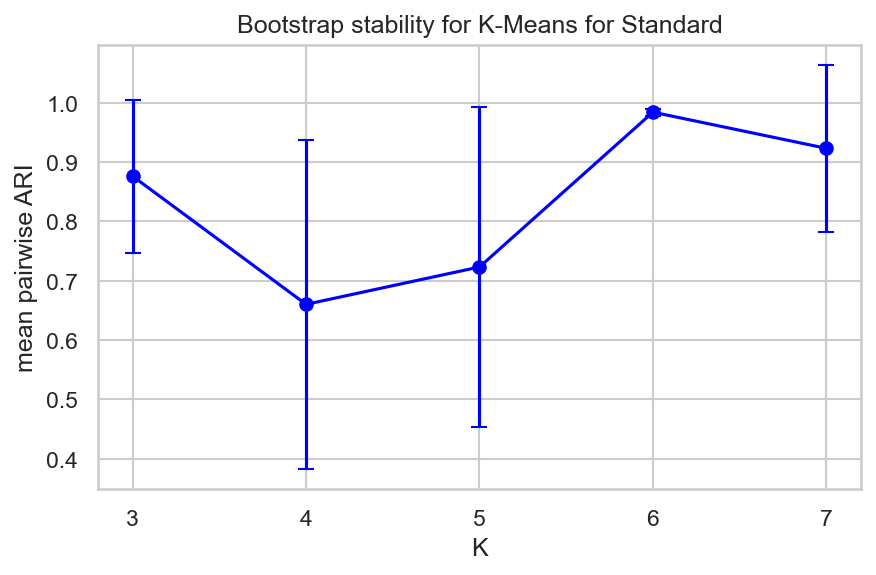

In [5]:
print("Running Bootstrap Stability for K-Means for Standard...")

stability_rows = []

for K in K_values:
    result = kmeans_bootstrap_stability(X_scaled_standard, K, n_boot=20, seed=42)
    
    stability_rows.append(
        {
            "K": K,
            "mean pairwise ARI": round(result["mean_ARI"], 3),
            "std ARI": round(result["std_ARI"], 3),
            "min ARI": round(result["min_ARI"], 3),
            "max ARI": round(result["max_ARI"], 3),
            "n compared resample pairs": result["n_pairs"],
        }
    )
    print(f"Finished K={K}: Mean ARI = {result['mean_ARI']:.3f} | Min = {result['min_ARI']:.3f} | Max = {result['max_ARI']:.3f}")

stability_df = pd.DataFrame(stability_rows)
display(stability_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    stability_df["K"],
    stability_df["mean pairwise ARI"],
    yerr=stability_df["std ARI"],
    marker="o",
    capsize=4,
    color="blue"
)
ax.set_title("Bootstrap stability for K-Means for Standard")
ax.set_xlabel("K")
ax.set_ylabel("mean pairwise ARI")

ax.set_xticks(stability_df["K"])

stability_df.to_csv(os.path.join(TAB_DIR, 'bootstrap_stability_standard.csv'), index=False)
fig.savefig(os.path.join(FIG_DIR, 'bootstrap_stability_standard.png'), bbox_inches='tight')

plt.tight_layout()
plt.show()

Running Bootstrap Stability for K-Means for Robust...
Finished K=3: Mean ARI = 0.876 | Min = 0.710 | Max = 0.998
Finished K=4: Mean ARI = 0.660 | Min = 0.194 | Max = 0.997
Finished K=5: Mean ARI = 0.723 | Min = 0.261 | Max = 0.997
Finished K=6: Mean ARI = 0.984 | Min = 0.968 | Max = 0.994
Finished K=7: Mean ARI = 0.923 | Min = 0.618 | Max = 0.997


,K,mean pairwise ARI,std ARI,min ARI,max ARI,n compared resample pairs
0,3,0.876,0.129,0.710,0.998,190
1,4,0.660,0.277,0.194,0.997,190
2,5,0.723,0.270,0.261,0.997,190
3,6,0.984,0.006,0.968,0.994,190
4,7,0.923,0.141,0.618,0.997,190


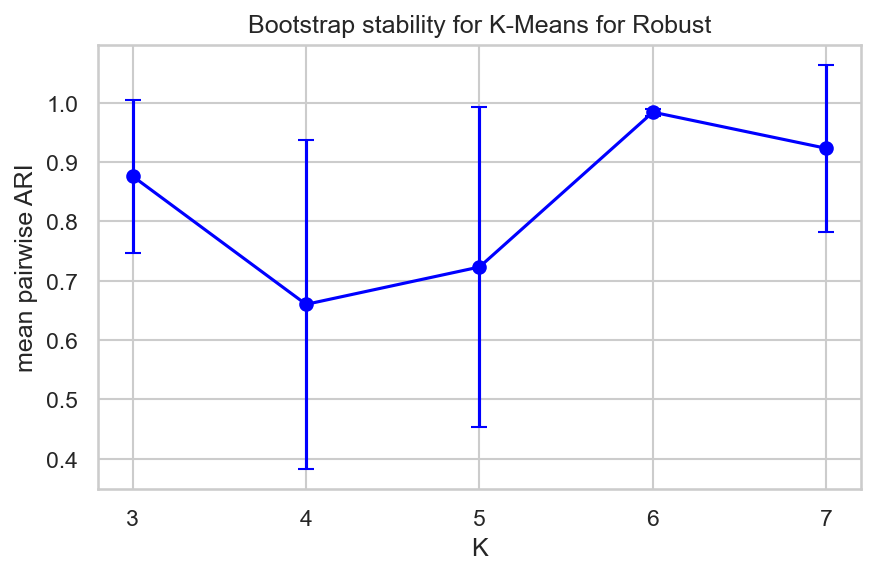

In [6]:
print("Running Bootstrap Stability for K-Means for Robust...")

stability_rows = []

for K in K_values:
    result = kmeans_bootstrap_stability(X_scaled_robust, K, n_boot=20, seed=42)
    
    stability_rows.append(
        {
            "K": K,
            "mean pairwise ARI": round(result["mean_ARI"], 3),
            "std ARI": round(result["std_ARI"], 3),
            "min ARI": round(result["min_ARI"], 3),
            "max ARI": round(result["max_ARI"], 3),
            "n compared resample pairs": result["n_pairs"],
        }
    )
    print(f"Finished K={K}: Mean ARI = {result['mean_ARI']:.3f} | Min = {result['min_ARI']:.3f} | Max = {result['max_ARI']:.3f}")

stability_df = pd.DataFrame(stability_rows)
display(stability_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    stability_df["K"],
    stability_df["mean pairwise ARI"],
    yerr=stability_df["std ARI"],
    marker="o",
    capsize=4,
    color="blue"
)
ax.set_title("Bootstrap stability for K-Means for Robust")
ax.set_xlabel("K")
ax.set_ylabel("mean pairwise ARI")

ax.set_xticks(stability_df["K"])

stability_df.to_csv(os.path.join(TAB_DIR, 'bootstrap_stability_robust.csv'), index=False)
fig.savefig(os.path.join(FIG_DIR, 'bootstrap_stability_robust.png'), bbox_inches='tight')

plt.tight_layout()
plt.show()

Calculating AIC & BIC for GMM
GMM K=3 concluído.
GMM K=4 concluído.
GMM K=5 concluído.
GMM K=6 concluído.
GMM K=7 concluído.
GMM K=8 concluído.


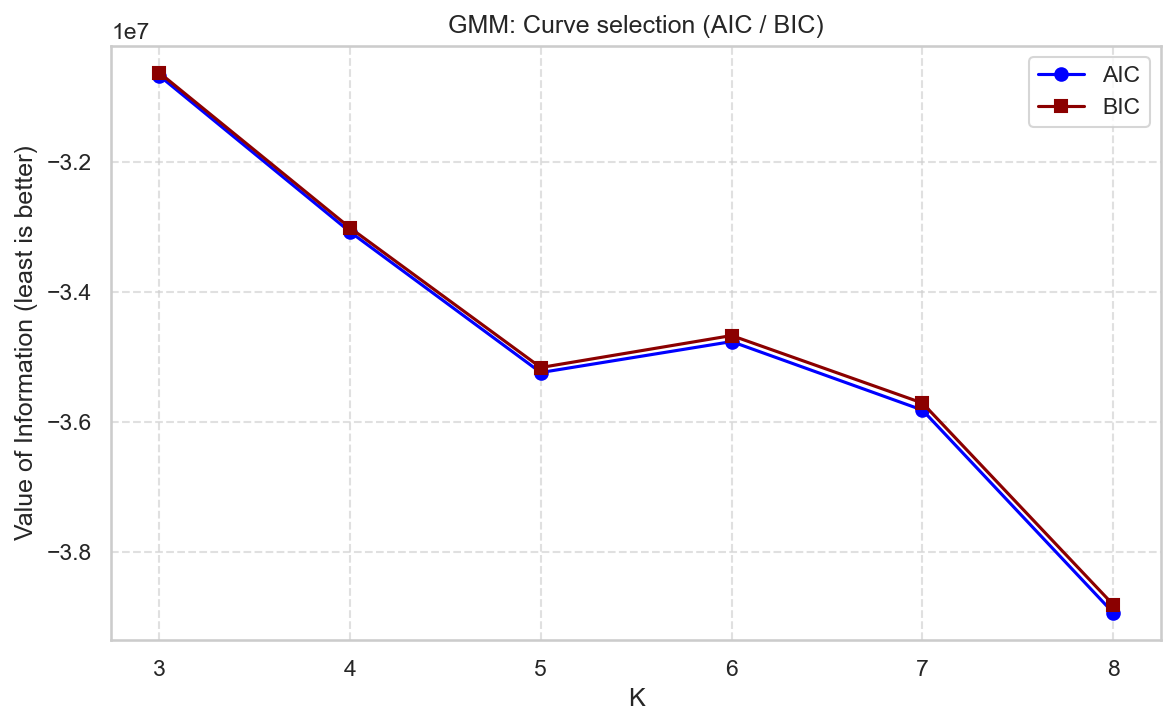

In [ ]:
print("Calculating AIC & BIC for GMM")

k_values = range(3, 9)
aics = []
bics = []

for K in k_values:
    gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=42, n_init=3)
    gmm.fit(X_scaled_standard)
    
    aics.append(gmm.aic(X_scaled_standard))
    bics.append(gmm.bic(X_scaled_standard))
    print(f"GMM K={K} completed.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, aics, label='AIC', marker='o', color='blue')
ax.plot(k_values, bics, label='BIC', marker='s', color='darkred')

ax.set_title("GMM: Curve selection (AIC / BIC)")
ax.set_xlabel("K")
ax.set_ylabel("Value of Information (least is better)")
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

fig.savefig(os.path.join(FIG_DIR, 'gmm_aic_bic_diagnostics.png'), bbox_inches='tight')

plt.tight_layout()
plt.show()

## 3.3 Optimal Model Profiling and Business Interpretation
Based on the stability and internal metrics, we proceed to profile the optimal model ($K=5$). To respect our segmentation time mapping, variables realized post-booking (such as `is_canceled` and `adr`) were not used to form the clusters. We now reintegrate them for post-hoc profiling to interpret the commercial and behavioral characteristics of each segment

In [ ]:
df_raw = pd.read_csv('../data/raw/hotel_bookings_course_release_v1.csv')
profiling_data = pd.read_csv('../tables/profiling_base_data.csv')

df_raw = df_raw[(df_raw['adr'] >= 0) & (df_raw['adr'] <= 5000)].copy()
df_raw.reset_index(drop=True, inplace=True)
profiling_data.reset_index(drop=True, inplace=True)

print("Fitting optimal K=5 model...")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled_standard)

df_interp = pd.DataFrame({
    'lead_time': df_raw['lead_time'],
    'total_nights': df_raw['stays_in_weekend_nights'] + df_raw['stays_in_week_nights'],
    'party_size': df_raw['adults'] + df_raw['children'].fillna(0) + df_raw['babies'],
    'previous_cancellations': df_raw['previous_cancellations']
})

df_interp['is_TA_TO'] = (df_raw['distribution_channel'] == 'TA/TO').astype(int)
df_interp['is_Direct'] = (df_raw['distribution_channel'] == 'Direct').astype(int)
df_interp['is_Transient'] = (df_raw['customer_type'] == 'Transient').astype(int)
df_interp['is_Non_Refund'] = (df_raw['deposit_type'] == 'Non Refund').astype(int)

df_interp['adr'] = profiling_data['adr']
df_interp['is_canceled'] = profiling_data['is_canceled']

df_interp['Cluster'] = labels

grand_mean = df_interp.drop('Cluster', axis=1).mean()
cluster_means = df_interp.groupby('Cluster').mean()

relative_diff = 100 * (cluster_means - grand_mean) / grand_mean

def color_magnitudes(val):
    """Colors large positive deviations red and large negative deviations blue."""
    if val > 50:
        color = "#bb0101"
    elif val > 20:
        color = "#D76262"
    elif val < -50:
        color = "#002E72"
    elif val < -20:
        color = "#5b7da9"
    else:
        color = 'white'
    return f'background-color: {color}'

styled_diff = relative_diff.T.style.map(color_magnitudes).format("{:.1f}%")
display(styled_diff)

relative_diff.to_csv('../tables/cluster_relative_differences.csv')

Fitting optimal K=5 model...


Cluster,0,1,2,3,4
lead_time,-85.3%,28.4%,104.6%,-92.8%,24.2%
total_nights,-49.8%,126.6%,-20.1%,-41.7%,-14.5%
party_size,-38.0%,13.7%,-5.9%,-12.5%,3.1%
previous_cancellations,567.3%,-97.2%,1687.9%,-99.9%,-100.0%
is_TA_TO,-81.7%,1.5%,12.4%,-28.3%,12.9%
is_Direct,74.2%,19.0%,-79.2%,128.1%,-54.2%
is_Transient,19.7%,3.5%,-31.1%,8.2%,-2.3%
is_Non_Refund,-96.4%,-86.3%,404.5%,-92.4%,29.5%
adr,-39.3%,10.8%,-23.6%,-7.7%,3.5%
is_canceled,-85.0%,-8.8%,167.0%,-62.2%,16.2%


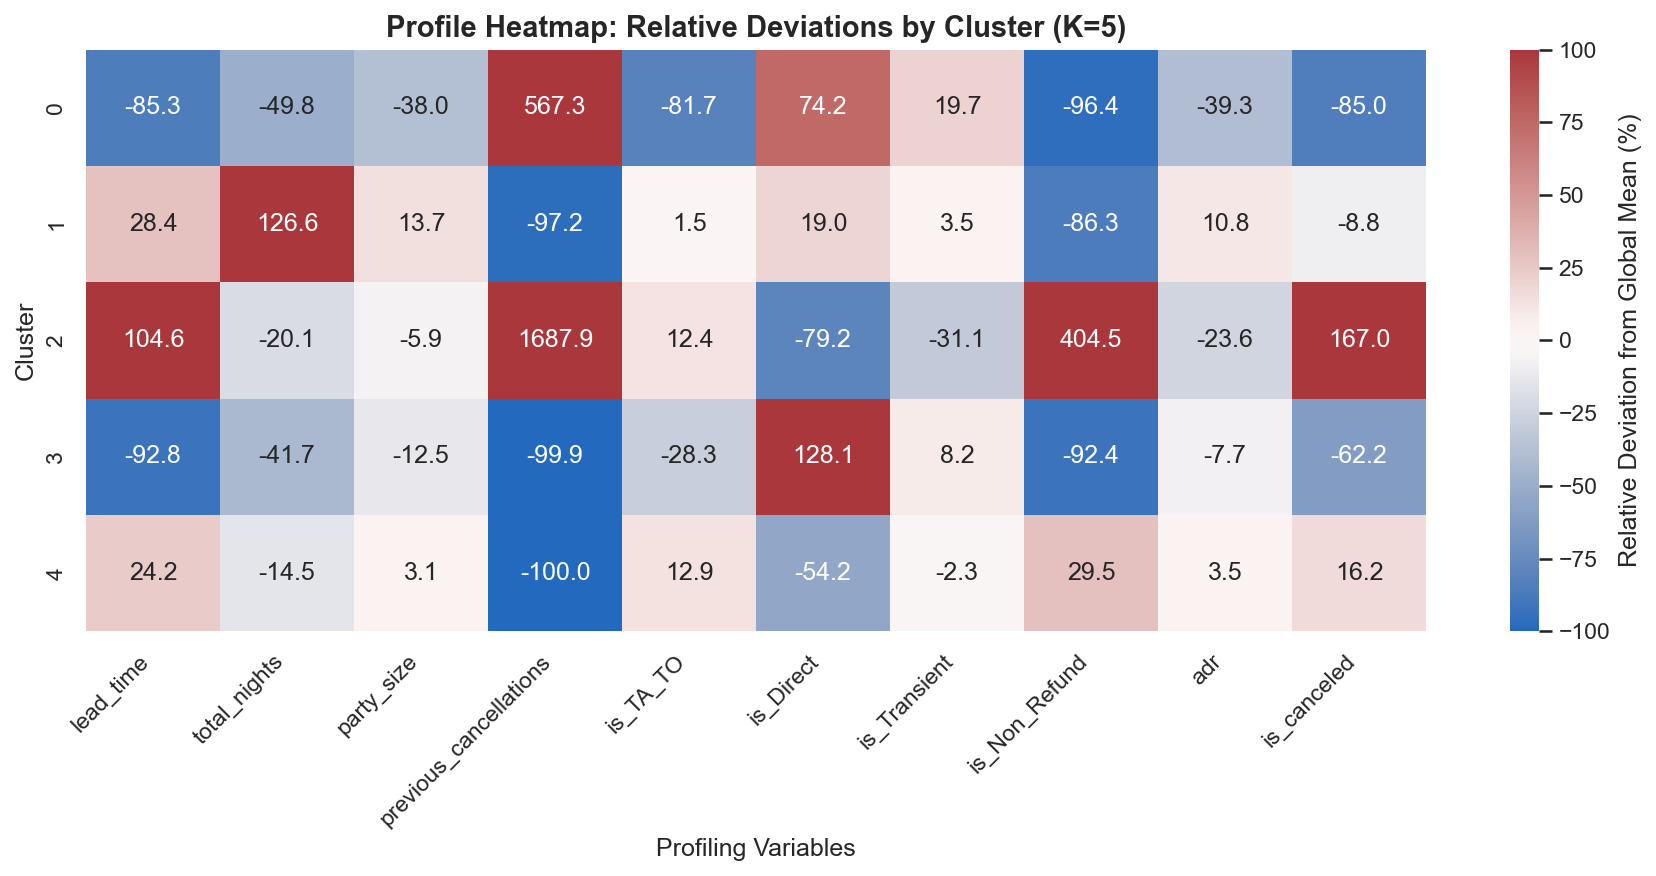

In [10]:
# Profiles heatmap

plt.figure(figsize=(12, 6))

sns.heatmap(relative_diff, annot=True, fmt=".1f", cmap="vlag", center=0, vmin=-100, vmax=100, 
            cbar_kws={'label': 'Relative Deviation from Global Mean (%)'})

plt.title('Profile Heatmap: Relative Deviations by Cluster (K=5)', fontweight='bold', fontsize=14)
plt.xlabel('Profiling Variables')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'heatmap_cluster_profiles.png'), bbox_inches='tight')
plt.show()

C:\Users\Afonso Simões\AppData\Local\Temp\ipykernel_39944\85654096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='lead_time', data=df_interp, palette='viridis')


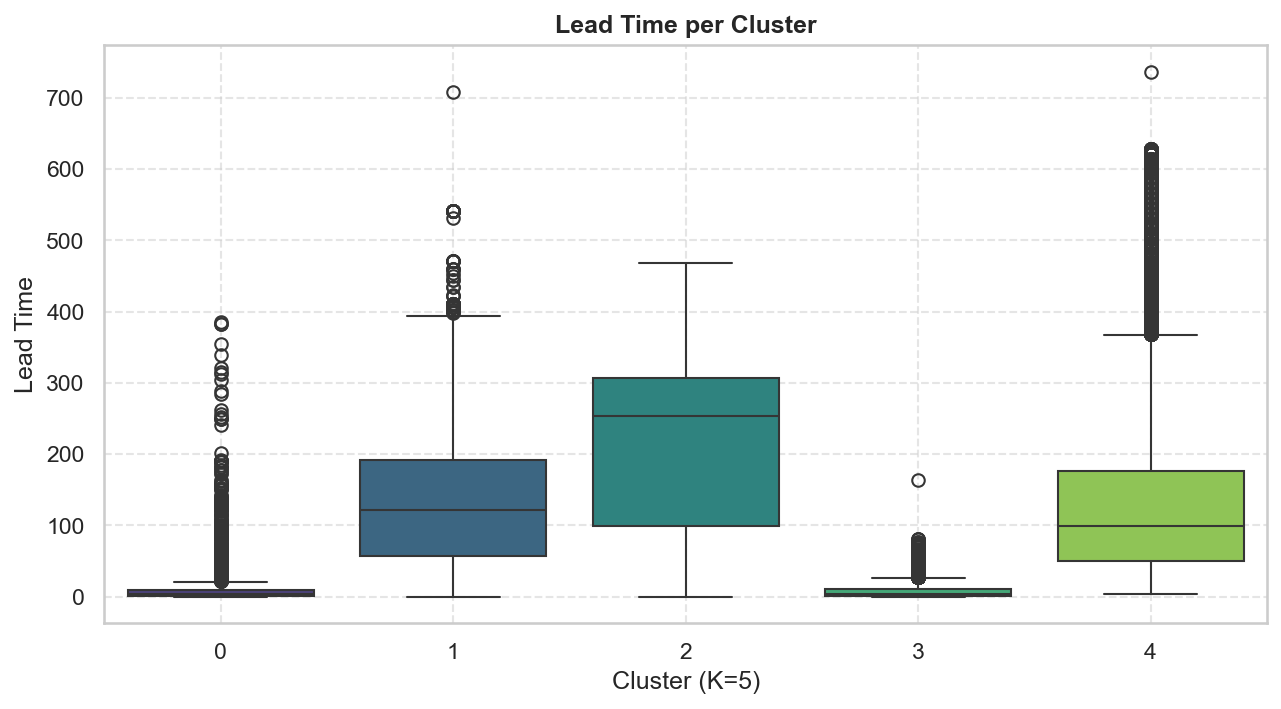

C:\Users\Afonso Simões\AppData\Local\Temp\ipykernel_39944\85654096.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='adr', data=df_interp[df_interp['adr'] < 500], palette='mako')


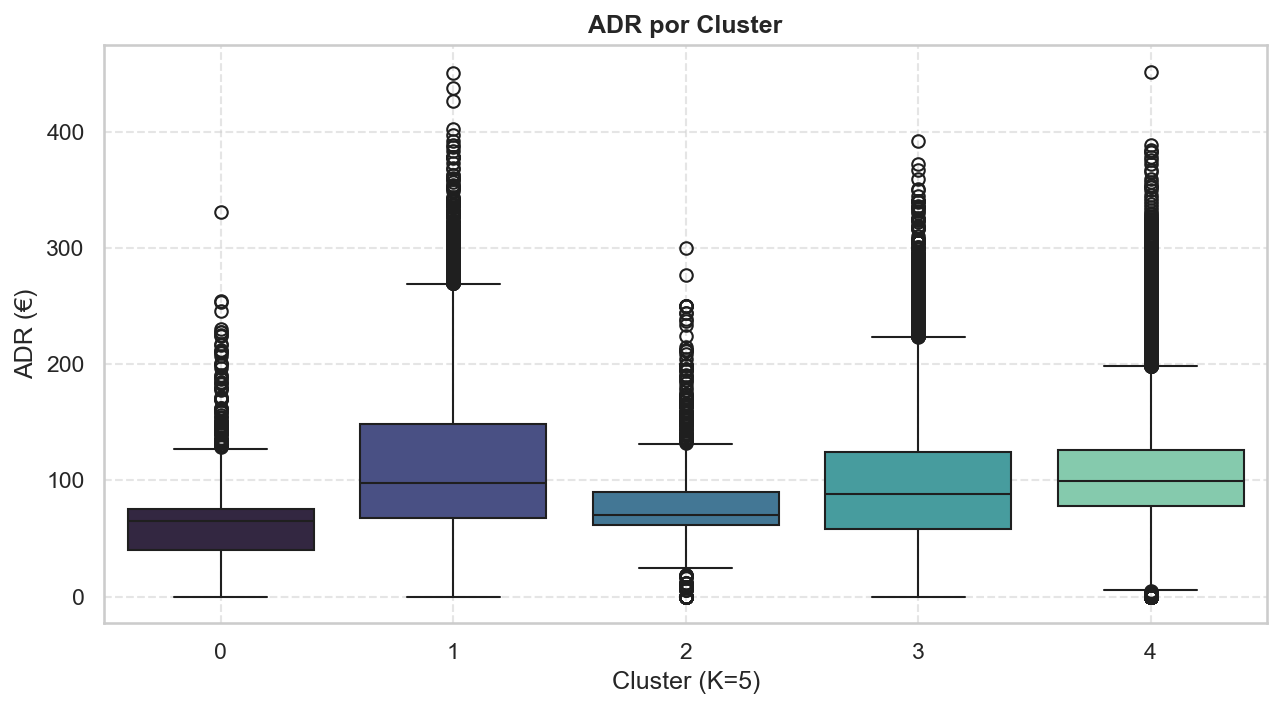

In [ ]:
# Profiling boxplots

plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='lead_time', data=df_interp, palette='viridis')
plt.title('Lead Time per Cluster', fontsize=12, fontweight='bold')
plt.xlabel('Cluster (K=5)')
plt.ylabel('Lead Time')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(os.path.join(FIG_DIR, 'boxplot_lead_time_by_cluster.png'), bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='adr', data=df_interp[df_interp['adr'] < 500], palette='mako')
plt.title('ADR per Cluster', fontsize=12, fontweight='bold')
plt.xlabel('Cluster (K=5)')
plt.ylabel('ADR (€)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(os.path.join(FIG_DIR, 'boxplot_adr_by_cluster.png'), bbox_inches='tight')
plt.show()

C:\Users\Afonso Simões\AppData\Local\Temp\ipykernel_39944\2109800586.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Rate_Cancel_Percent', data=cancel_stats, palette='Reds', ax=ax1)


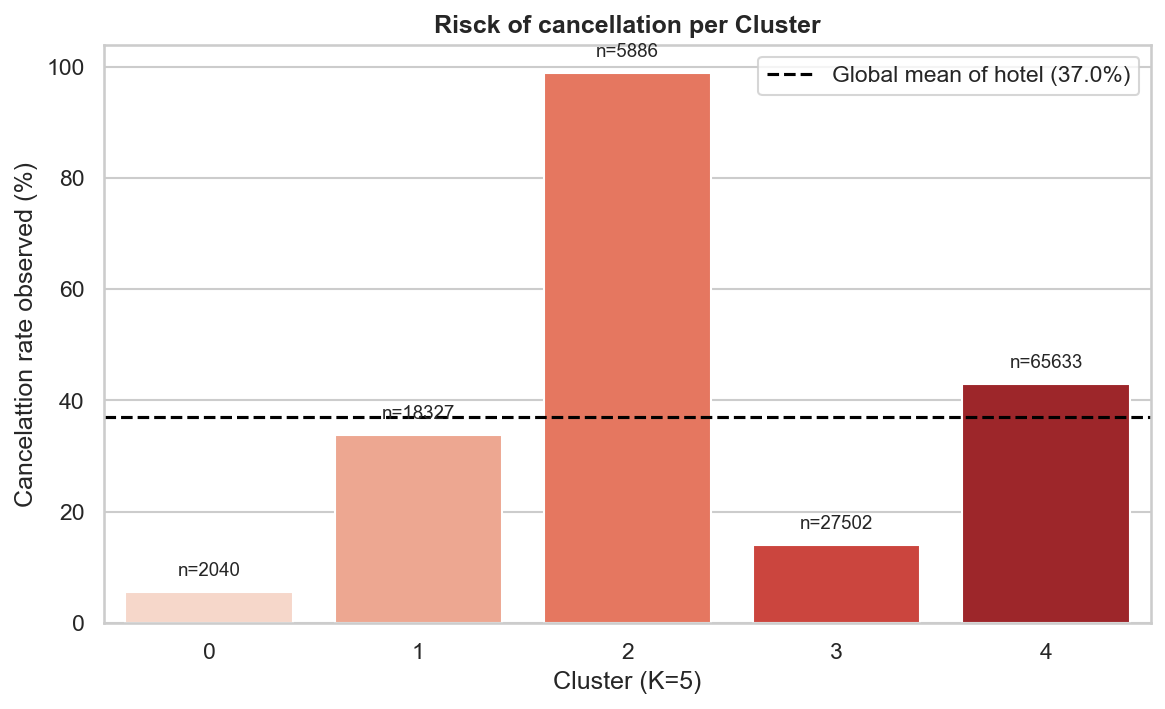

In [ ]:
# Cancellation rate per Cluster

cancel_stats = df_interp.groupby('Cluster').agg(
    Num_Reservations=('is_canceled', 'count'),
    Rate_Cancel_Percent=('is_canceled', lambda x: x.mean() * 100)
).reset_index()

global_cancel_rate = df_interp['is_canceled'].mean() * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

sns.barplot(x='Cluster', y='Rate_Cancel_Percent', data=cancel_stats, palette='Reds', ax=ax1)

ax1.axhline(y=global_cancel_rate, color='black', linestyle='--', label=f'Global mean of hotel ({global_cancel_rate:.1f}%)')

ax1.set_title('Risk of cancellation per Cluster', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cancellation rate observed (%)')
ax1.set_xlabel('Cluster (K=5)')
ax1.legend()

for i, p in enumerate(ax1.patches):
    ax1.annotate(f"n={int(cancel_stats['Num_Reservations'][i])}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)

plt.savefig(os.path.join(FIG_DIR, 'bar_cancellation_risk_by_cluster.png'), bbox_inches='tight')
plt.show()

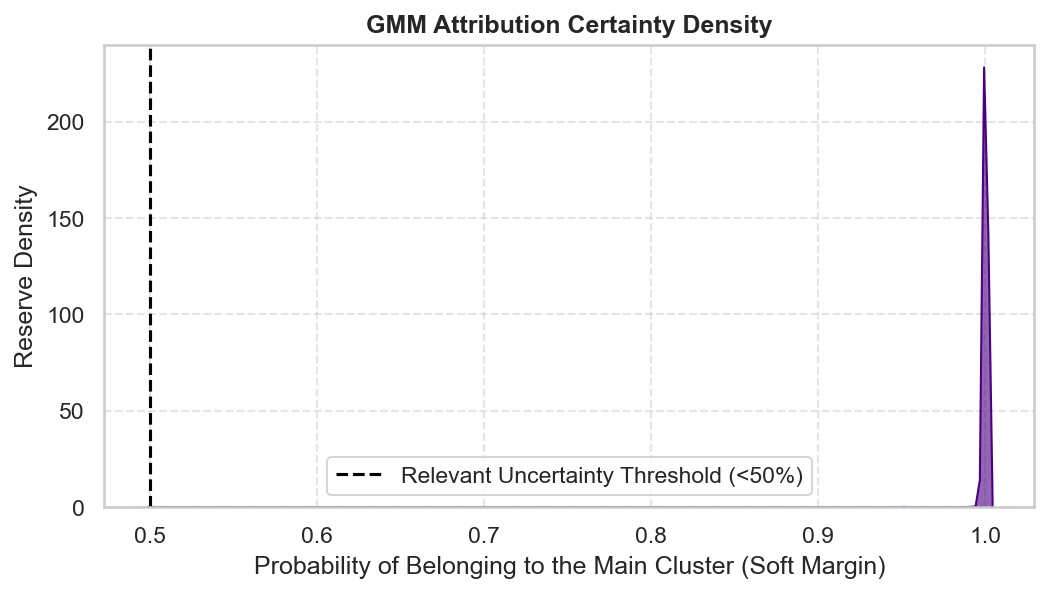

Percentage of pooled reserves with more than 80% mathematical confidence.: 99.9%


In [ ]:
# GMM Soft Clustering & Certainty

best_gmm_k = 5 # Based on the AIC & BIC choose K = 5 (5 is plateau, 8 is probably overfitting)
optimal_gmm = GaussianMixture(n_components=best_gmm_k, covariance_type='full', random_state=42, n_init=3)
optimal_gmm.fit(X_scaled_standard)

probs = optimal_gmm.predict_proba(X_scaled_standard)

max_certainty = np.max(probs, axis=1)

plt.figure(figsize=(8, 4))
sns.kdeplot(max_certainty, fill=True, color='indigo', alpha=0.6)
plt.title('GMM Attribution Certainty Density', fontweight='bold')
plt.xlabel('Probability of Belonging to the Main Cluster (Soft Margin)')
plt.ylabel('Density')

plt.axvline(x=0.5, color='black', linestyle='--', label='Relevant Uncertainty Threshold (<50%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(os.path.join(FIG_DIR, 'gmm_classification_certainty.png'), bbox_inches='tight')
plt.show()

high_certainty = (max_certainty > 0.80).mean() * 100
print(f"Percentage of pooled reserves with more than 80% mathematical confidence.: {high_certainty:.1f}%")

In [ ]:
labels_gmm = optimal_gmm.predict(X_scaled_standard)

ari_cross_family = adjusted_rand_score(labels, labels_gmm)
print(f"ARI between K-Means (K=5) and GMM (K=5): {ari_cross_family:.4f}")

try:
    df_logs = pd.read_csv('../tables/experiments.csv')
    
    if 'method' in df_logs.columns:
        family_comparison = df_logs[
                (df_logs['k'] == 5) & 
                (df_logs['seed'].astype(str) == '42') & 
                (df_logs['method'].isin(['k-means', 'gmm']))
            ][['method', 'k', 'silhouette', 'davies_bouldin', 'calinski_harabasz', 'runtime_seconds']]

        print("\nSide-by-Side Comparison (K=5)")
        display(family_comparison)
    else:
        print("Run `python run_all.py` first to ensure 'gmm' results are in experiments.csv")

except FileNotFoundError:
    print("Error: experiments.csv not found. Please check your tables directory.")

ARI between K-Means (K=5) and GMM (K=5): 0.0612

Side-by-Side Comparison (K=5)


,method,k,silhouette,davies_bouldin,calinski_harabasz,runtime_seconds
10,k-means,5,0.157022,1.675839,15819.871893,1.092451
40,gmm,5,0.017935,4.614579,2674.676020,11.872225


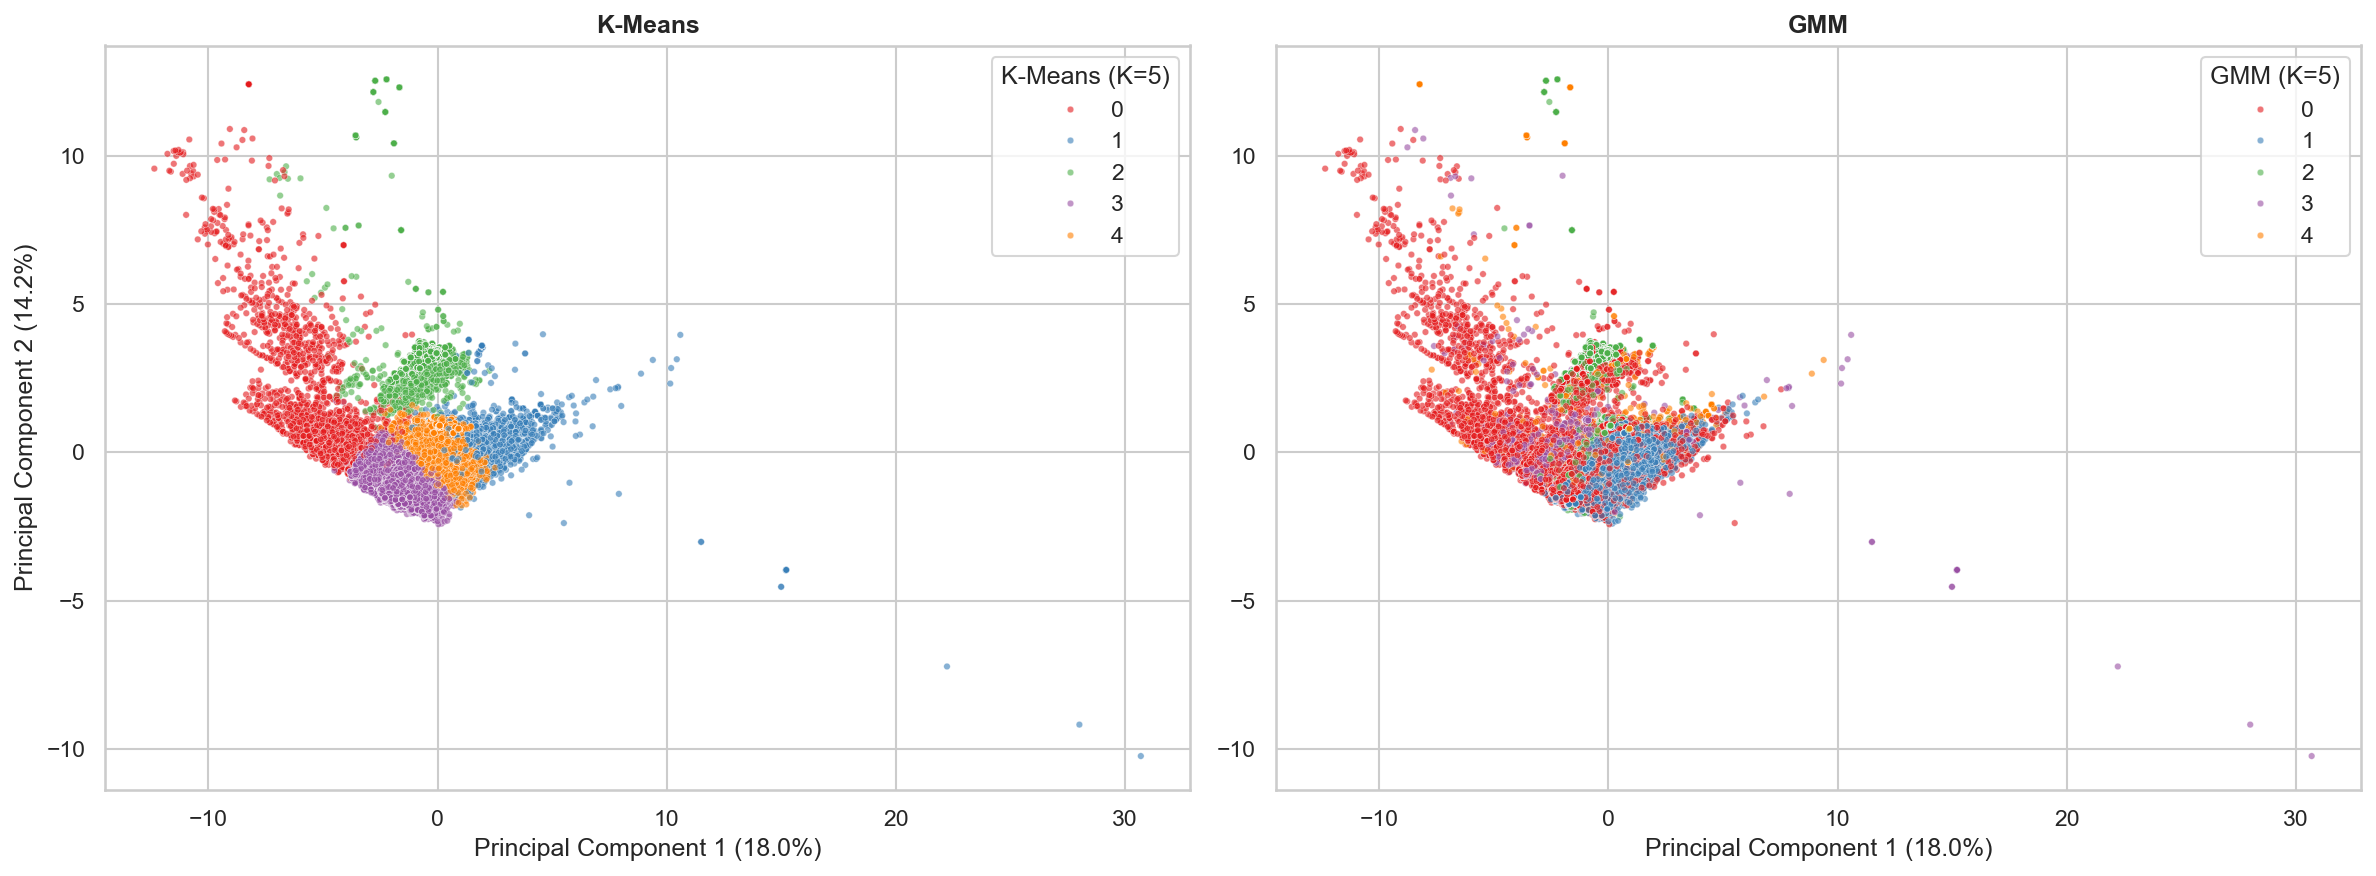

In [ ]:
# K-Means vs GMM (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_standard)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['K-Means (K=5)'] = labels
df_pca['GMM (K=5)'] = labels_gmm

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='K-Means (K=5)', 
    palette='Set1', s=10, alpha=0.6, ax=axes[0]
)
axes[0].set_title('K-Means', fontweight='bold')
axes[0].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='GMM (K=5)', 
    palette='Set1', s=10, alpha=0.6, ax=axes[1]
)
axes[1].set_title('GMM', fontweight='bold')
axes[1].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_comparison_kmeans_vs_gmm.png'), dpi=300, bbox_inches='tight')
plt.show()

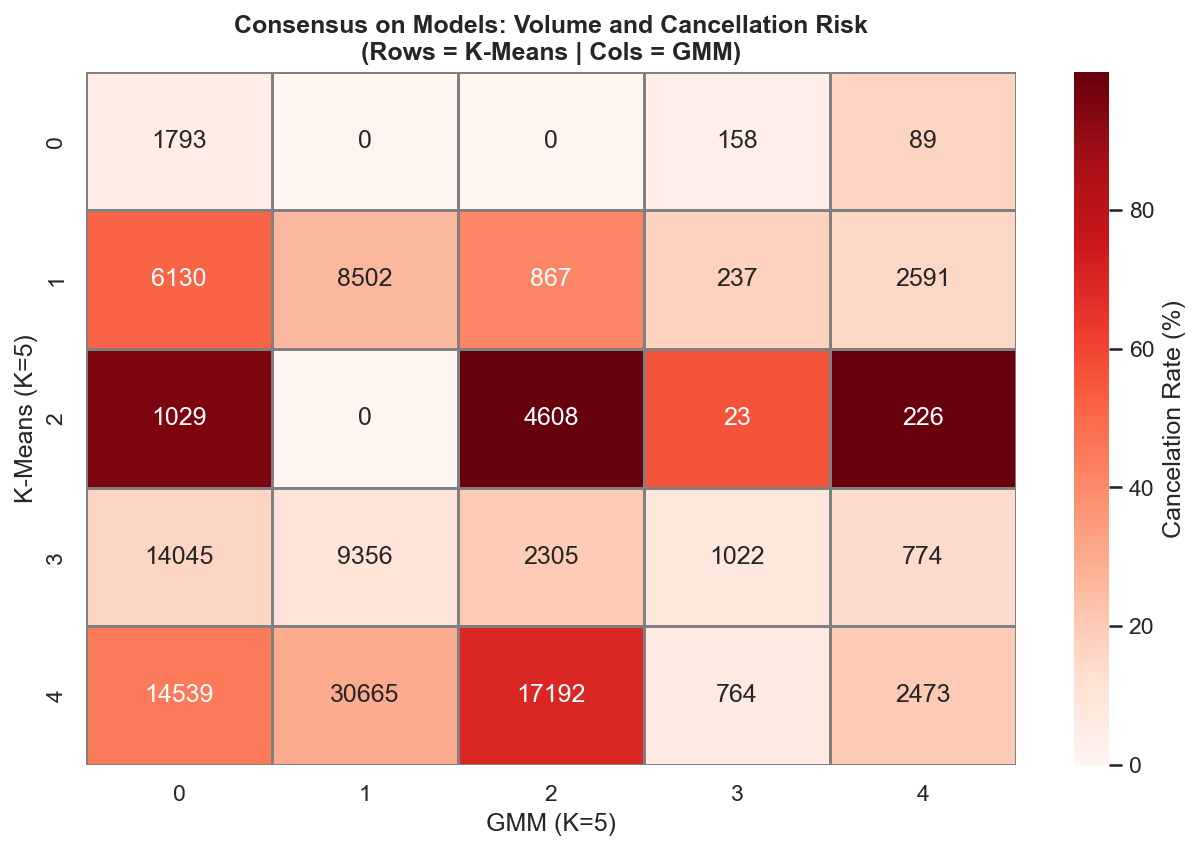

In [ ]:
# K-MEANS VS GMM CONSENSUS MATRIX

df_interp['Cluster_GMM'] = labels_gmm

cross_stats = df_interp.groupby(['Cluster', 'Cluster_GMM']).agg(
    Cancel_Rate=('is_canceled', 'mean'),
    Volume=('is_canceled', 'count')
).reset_index()

cross_stats['Cancel_Rate'] *= 100

pivot_rate = cross_stats.pivot(index='Cluster', columns='Cluster_GMM', values='Cancel_Rate').fillna(0)
pivot_vol = cross_stats.pivot(index='Cluster', columns='Cluster_GMM', values='Volume').fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_rate, annot=pivot_vol, fmt=".0f", cmap="Reds", 
            cbar_kws={'label': 'Cancellation Rate (%)'},
            linewidths=.5, linecolor='gray')

plt.title('Consensus on Models: Volume and Cancellation Risk\n(Rows = K-Means | Cols = GMM)', fontweight='bold')
plt.xlabel('GMM (K=5)')
plt.ylabel('K-Means (K=5)')

plt.savefig(os.path.join(FIG_DIR, 'heatmap_consensus_models.png'), bbox_inches='tight')
plt.show()